In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import spacy
import joblib
from datasets import load_dataset
from sklearn.metrics import f1_score, precision_score, recall_score, classification_report, confusion_matrix

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42

# Загружаем артефакты обученной модели
artifacts = joblib.load('../models/turn_detector.pkl')
model = artifacts['model']
ohe = artifacts['ohe']
NUMERIC_FEATURES = artifacts['numeric_features']
CATEGORICAL_FEATURES = artifacts['categorical_features']
THRESHOLD = artifacts['threshold']
FEATURE_COLUMNS = artifacts['feature_columns']

print(f"Модель: {type(model).__name__}")
print(f"Порог: {THRESHOLD}")
print(f"Признаков: {len(FEATURE_COLUMNS)}")

# Также понадобятся train-данные MultiWOZ для сравнения распределений
train_df_multiwoz = pd.read_parquet('../data/processed.parquet')
print(f"\nMultiWOZ processed: {len(train_df_multiwoz):,} строк")

Модель: LGBMClassifier
Порог: 0.8699999999999999
Признаков: 22

MultiWOZ processed: 153,983 строк


In [4]:
# ds_daily = load_dataset("daily_dialog", split="test", trust_remote_code=True)
ds_daily = load_dataset("roskoN/dailydialog", split="test")
print(f"Диалогов в DailyDialog test: {len(ds_daily)}")
print(f"Поля: {ds_daily.features}")
print()
print("Пример диалога:")
print(ds_daily[0])

Generating train split:   0%|          | 0/11118 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Диалогов в DailyDialog test: 1000
Поля: {'id': Value(dtype='string', id=None), 'acts': Sequence(feature=Value(dtype='int8', id=None), length=-1, id=None), 'emotions': Sequence(feature=Value(dtype='int8', id=None), length=-1, id=None), 'utterances': Sequence(feature=Value(dtype='string', id=None), length=-1, id=None)}

Пример диалога:
{'id': 'ef13ae7a7502181b0f98b2e5b417aad98550672fada48a4fbd94f4d6aa995ba1_0', 'acts': [3, 2, 3, 4, 3, 4, 3, 2, 3, 4, 2, 3], 'emotions': [0, 6, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0], 'utterances': ['Hey man , you wanna buy some weed ?', 'Some what ?', 'Weed ! You know ? Pot , Ganja , Mary Jane some chronic !', 'Oh , umm , no thanks .', 'I also have blow if you prefer to do a few lines .', 'No , I am ok , really .', 'Come on man ! I even got dope and acid ! Try some !', 'Do you really have all of these drugs ? Where do you get them from ?', 'I got my connections ! Just tell me what you want and I ’ ll even give you one ounce for free .', 'Sounds good ! Let ’ s see , 

In [6]:
def daily_dialog_to_prefixes(dialog_idx, dialog):
    """В DailyDialog нет user/system — берём все реплики как разговорную речь."""
    rows = []
    for turn_idx, utterance in enumerate(dialog['utterances']):  # ← было 'dialog'
        text = utterance.strip()
        if not text:
            continue
        words = text.split()
        n = len(words)
        for i in range(1, n + 1):
            prefix = " ".join(words[:i])
            rows.append({
                "dialogue_id": f"daily_{dialog_idx}",
                "turn_id": turn_idx,
                "prefix_text": prefix,
                "is_end": int(i == n),
            })
    return rows


N_DIALOGS_DAILY = min(len(ds_daily), 1000)

all_rows = []
for i in range(N_DIALOGS_DAILY):
    all_rows.extend(daily_dialog_to_prefixes(i, ds_daily[i]))

df_daily = pd.DataFrame(all_rows)
print(f"Префиксов: {len(df_daily):,}")
print(f"Диалогов:  {df_daily['dialogue_id'].nunique()}")
print(f"Доля is_end=1: {df_daily['is_end'].mean():.3f}")
df_daily.head(10)

Префиксов: 106,631
Диалогов:  1000
Доля is_end=1: 0.073


,dialogue_id,turn_id,prefix_text,is_end
0,daily_0,0,Hey,0
1,daily_0,0,Hey man,0
2,daily_0,0,"Hey man ,",0
3,daily_0,0,"Hey man , you",0
4,daily_0,0,"Hey man , you wanna",0
5,daily_0,0,"Hey man , you wanna buy",0
6,daily_0,0,"Hey man , you wanna buy some",0
7,daily_0,0,"Hey man , you wanna buy some weed",0
8,daily_0,0,"Hey man , you wanna buy some weed ?",1
9,daily_0,1,Some,0


In [7]:
nlp = spacy.load("en_core_web_sm", disable=["ner", "parser", "lemmatizer"])

# Базовые признаки
df_daily['length_words'] = df_daily['prefix_text'].str.split().str.len()
df_daily['length_chars'] = df_daily['prefix_text'].str.len()
df_daily['last_word'] = df_daily['prefix_text'].str.split().str[-1].str.lower()
df_daily['ends_with_punct'] = df_daily['prefix_text'].str.rstrip().str[-1].isin(['.', '?', '!']).astype(int)

QUESTION_WORDS = {"what", "where", "when", "who", "why", "how", "which", "whose"}
df_daily['has_question_word'] = df_daily['prefix_text'].str.lower().apply(
    lambda t: int(any(w in t.split() for w in QUESTION_WORDS))
)

# POS-тег через spaCy
unique_last_words = df_daily['last_word'].unique()
pos_map = {}
for doc in nlp.pipe(unique_last_words, batch_size=500):
    pos_map[doc.text] = doc[0].pos_ if len(doc) > 0 else "X"

df_daily['last_pos'] = df_daily['last_word'].map(pos_map)
df_daily['ends_with_prep'] = (df_daily['last_pos'] == "ADP").astype(int)

print("Фичи рассчитаны")
df_daily.head()

Фичи рассчитаны


,dialogue_id,turn_id,prefix_text,is_end,length_words,length_chars,last_word,ends_with_punct,has_question_word,last_pos,ends_with_prep
0,daily_0,0,Hey,0,1,3,hey,0,0,INTJ,0
1,daily_0,0,Hey man,0,2,7,man,0,0,NOUN,0
2,daily_0,0,"Hey man ,",0,3,9,",",0,0,PUNCT,0
3,daily_0,0,"Hey man , you",0,4,13,you,0,0,PRON,0
4,daily_0,0,"Hey man , you wanna",0,5,19,wanna,0,0,NOUN,0


In [8]:
# Признаки в том же виде что и при обучении
X_daily_raw = df_daily[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y_daily = df_daily['is_end'].values

# One-hot encode через ohe из обучения (handle_unknown='ignore' спасёт от новых POS)
X_daily_ohe = pd.DataFrame(
    ohe.transform(X_daily_raw[CATEGORICAL_FEATURES]),
    columns=ohe.get_feature_names_out(CATEGORICAL_FEATURES),
    index=X_daily_raw.index
)

X_daily = pd.concat([X_daily_raw[NUMERIC_FEATURES], X_daily_ohe], axis=1)

# Убеждаемся что порядок столбцов идентичен train
X_daily = X_daily[FEATURE_COLUMNS]

print(f"X_daily shape: {X_daily.shape}")
print(f"Совпадают столбцы с train: {list(X_daily.columns) == FEATURE_COLUMNS}")

X_daily shape: (106631, 22)
Совпадают столбцы с train: True


In [9]:
# Предсказываем — используем модель и порог из сохранённых артефактов
y_proba_daily = model.predict_proba(X_daily)[:, 1]
y_pred_daily = (y_proba_daily > THRESHOLD).astype(int)

# Метрики на DailyDialog
f1_daily = f1_score(y_daily, y_pred_daily)
precision_daily = precision_score(y_daily, y_pred_daily)
recall_daily = recall_score(y_daily, y_pred_daily)

print("=== Модель LightGBM на DailyDialog (out-of-domain) ===")
print(f"F1-score:  {f1_daily:.4f}")
print(f"Precision: {precision_daily:.4f}")
print(f"Recall:    {recall_daily:.4f}")
print()
print(classification_report(y_daily, y_pred_daily, target_names=['не конец', 'конец']))

cm = confusion_matrix(y_daily, y_pred_daily)
print("Confusion matrix:")
print(f"                  Predicted")
print(f"                  не конец  конец")
print(f"Actual не конец    {cm[0,0]:>6}  {cm[0,1]:>6}")
print(f"Actual конец       {cm[1,0]:>6}  {cm[1,1]:>6}")

=== Модель LightGBM на DailyDialog (out-of-domain) ===
F1-score:  0.7733
Precision: 0.6890
Recall:    0.8810

              precision    recall  f1-score   support

    не конец       0.99      0.97      0.98     98891
       конец       0.69      0.88      0.77      7740

    accuracy                           0.96    106631
   macro avg       0.84      0.92      0.88    106631
weighted avg       0.97      0.96      0.96    106631

Confusion matrix:
                  Predicted
                  не конец  конец
Actual не конец     95813    3078
Actual конец          921    6819


=== Деградация модели на out-of-domain данных ===
      Метрика  MultiWOZ (in-domain)  DailyDialog (out-of-domain)  Деградация
           F1              0.826749                     0.773261    0.053488
    Precision              0.772204                     0.688997    0.083208
       Recall              0.889584                     0.881008    0.008576
Доля is_end=1              0.086761                     0.072587    0.014174


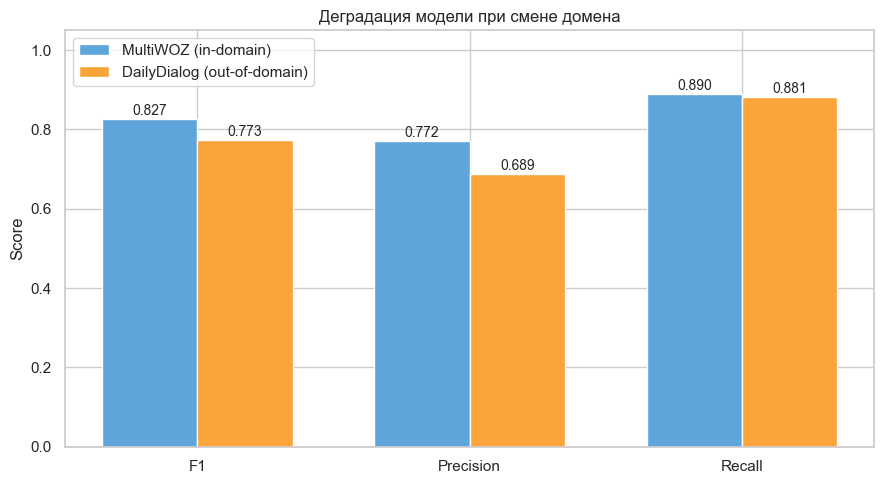

In [10]:
# Метрики на MultiWOZ test уже посчитаны на Этапе 2 — берём их из памяти
# Если не помнишь — пересчитаем сейчас на лету
from sklearn.metrics import f1_score

# Загружаем processed.parquet, делаем точно такой же split что и при обучении
from sklearn.model_selection import GroupShuffleSplit
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, test_idx = next(splitter.split(train_df_multiwoz, groups=train_df_multiwoz['dialogue_id']))
test_df = train_df_multiwoz.iloc[test_idx].copy()

X_test_raw = test_df[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y_test = test_df['is_end'].values
X_test_ohe = pd.DataFrame(
    ohe.transform(X_test_raw[CATEGORICAL_FEATURES]),
    columns=ohe.get_feature_names_out(CATEGORICAL_FEATURES),
    index=X_test_raw.index
)
X_test = pd.concat([X_test_raw[NUMERIC_FEATURES], X_test_ohe], axis=1)
X_test = X_test[FEATURE_COLUMNS]

y_proba_test = model.predict_proba(X_test)[:, 1]
y_pred_test = (y_proba_test > THRESHOLD).astype(int)

f1_multiwoz = f1_score(y_test, y_pred_test)
precision_multiwoz = precision_score(y_test, y_pred_test)
recall_multiwoz = recall_score(y_test, y_pred_test)

# Таблица сравнения
comparison = pd.DataFrame({
    'Метрика': ['F1', 'Precision', 'Recall', 'Доля is_end=1'],
    'MultiWOZ (in-domain)': [f1_multiwoz, precision_multiwoz, recall_multiwoz, y_test.mean()],
    'DailyDialog (out-of-domain)': [f1_daily, precision_daily, recall_daily, y_daily.mean()],
})
comparison['Деградация'] = comparison['MultiWOZ (in-domain)'] - comparison['DailyDialog (out-of-domain)']

print("=== Деградация модели на out-of-domain данных ===")
print(comparison.to_string(index=False))

# Визуализация
metrics = ['F1', 'Precision', 'Recall']
multiwoz_vals = [f1_multiwoz, precision_multiwoz, recall_multiwoz]
daily_vals = [f1_daily, precision_daily, recall_daily]

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(metrics))
width = 0.35
ax.bar(x - width/2, multiwoz_vals, width, label='MultiWOZ (in-domain)', color='#5DA5DA')
ax.bar(x + width/2, daily_vals, width, label='DailyDialog (out-of-domain)', color='#FAA43A')

# Подписи значений
for i, (m, d) in enumerate(zip(multiwoz_vals, daily_vals)):
    ax.text(i - width/2, m + 0.01, f'{m:.3f}', ha='center', fontsize=10)
    ax.text(i + width/2, d + 0.01, f'{d:.3f}', ha='center', fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel('Score')
ax.set_title('Деградация модели при смене домена')
ax.set_ylim(0, 1.05)
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/drift_metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


|Метрика|MultiWOZ|DailyDialog|Δ|
|---|---|---|---|
|F1|~0.83|0.77|**−0.06**|
|Precision|~0.77|0.69|**−0.08** ← главная просадка|
|Recall|~0.88|0.88|0|

**Что произошло:** Recall не изменился — модель ловит концы реплик так же хорошо. Но Precision упал — стало больше **ложных срабатываний** (модель считает «конец», когда это не конец).  
**Почему так:** в DailyDialog знаки препинания отделены пробелами (`"man ,"` вместо `"man,"`), и `last_word` стал чаще быть запятой/точкой. Признак `ends_with_punct` начал срабатывать в середине реплики, где раньше не срабатывал. Это **именно тот feature drift**, который покажем количественно через PSI.

In [11]:
def calculate_psi(train_values, prod_values, n_bins=10):
    """
    PSI между train и production распределениями признака.
    
    Для числовых: разбиваем train на n_bins квантилей, считаем доли в каждом.
    Для категориальных: используем уникальные категории как бины.
    """
    eps = 1e-6  # чтобы избежать log(0)
    
    # Определяем границы по train (важно — не по prod!)
    if pd.api.types.is_numeric_dtype(train_values):
        # Числовой: квантильные бины
        bins = np.quantile(train_values, np.linspace(0, 1, n_bins + 1))
        bins = np.unique(bins)  # дедуплицируем (если много одинаковых значений)
        if len(bins) < 2:
            return 0.0  # константный признак — drift не считается
        train_counts, _ = np.histogram(train_values, bins=bins)
        prod_counts, _ = np.histogram(prod_values, bins=bins)
    else:
        # Категориальный: используем все категории из train
        categories = pd.Series(train_values).unique()
        train_counts = pd.Series(train_values).value_counts().reindex(categories, fill_value=0).values
        prod_counts = pd.Series(prod_values).value_counts().reindex(categories, fill_value=0).values
    
    # Доли (а не абсолютные количества)
    train_props = train_counts / max(train_counts.sum(), 1)
    prod_props = prod_counts / max(prod_counts.sum(), 1)
    
    # Защита от нулей
    train_props = np.clip(train_props, eps, 1)
    prod_props = np.clip(prod_props, eps, 1)
    
    psi = np.sum((prod_props - train_props) * np.log(prod_props / train_props))
    return psi


# Берём train MultiWOZ (НЕ test) — он использовался при обучении
train_idx_for_psi, _ = next(splitter.split(train_df_multiwoz, groups=train_df_multiwoz['dialogue_id']))
train_for_psi = train_df_multiwoz.iloc[train_idx_for_psi]

# Считаем PSI по всем признакам
psi_results = []
all_features = NUMERIC_FEATURES + CATEGORICAL_FEATURES

for feature in all_features:
    psi = calculate_psi(train_for_psi[feature], df_daily[feature])
    psi_results.append({'feature': feature, 'psi': psi})

# Добавим PSI по самой целевой переменной — label shift
psi_target = calculate_psi(train_for_psi['is_end'], df_daily['is_end'])
psi_results.append({'feature': 'is_end (target)', 'psi': psi_target})

psi_df = pd.DataFrame(psi_results).sort_values('psi', ascending=False)
print("=== PSI по признакам (train MultiWOZ vs DailyDialog) ===")
print(psi_df.to_string(index=False))

=== PSI по признакам (train MultiWOZ vs DailyDialog) ===
          feature      psi
         last_pos 1.056556
     length_words 0.084678
     length_chars 0.055190
  ends_with_punct 0.000000
   ends_with_prep 0.000000
has_question_word 0.000000
  is_end (target) 0.000000


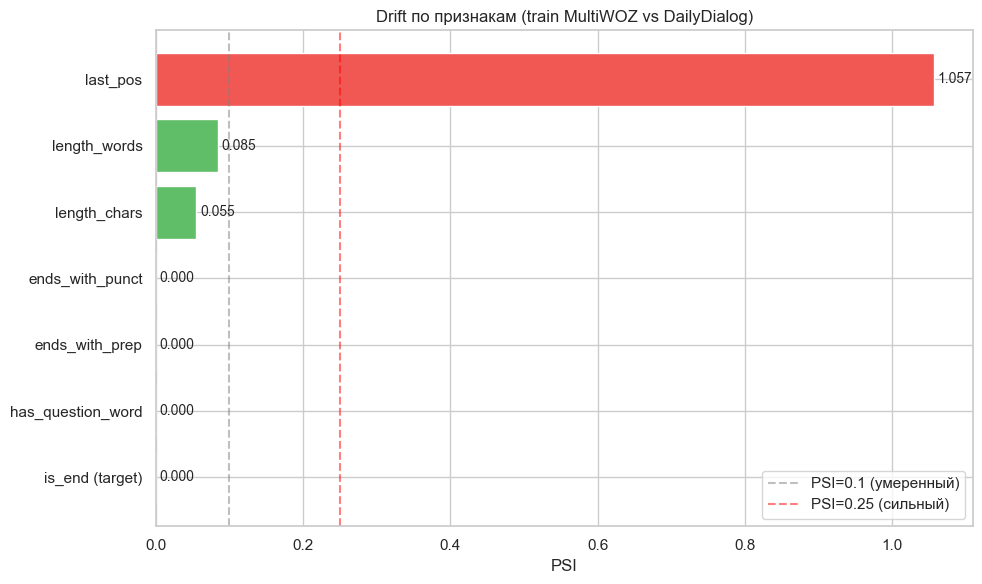

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#60BD68' if p < 0.1 else '#FAA43A' if p < 0.25 else '#F15854' 
          for p in psi_df['psi']]

bars = ax.barh(psi_df['feature'], psi_df['psi'], color=colors)

# Подписи значений
for bar, psi in zip(bars, psi_df['psi']):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{psi:.3f}', va='center', fontsize=10)

# Пороги
ax.axvline(0.1, color='gray', linestyle='--', alpha=0.5, label='PSI=0.1 (умеренный)')
ax.axvline(0.25, color='red', linestyle='--', alpha=0.5, label='PSI=0.25 (сильный)')

ax.set_xlabel('PSI')
ax.set_title('Drift по признакам (train MultiWOZ vs DailyDialog)')
ax.legend(loc='lower right')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../reports/figures/psi_drift.png', dpi=150, bbox_inches='tight')
plt.show()

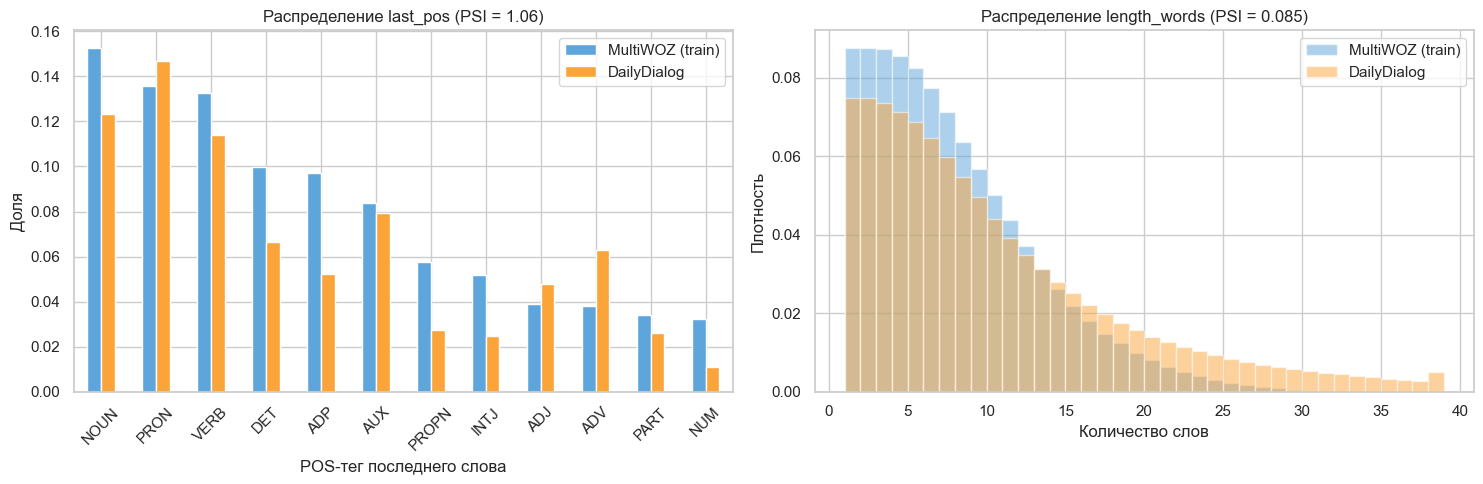

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Distribution of last_pos: MultiWOZ vs DailyDialog
pos_train = train_for_psi['last_pos'].value_counts(normalize=True)
pos_daily = df_daily['last_pos'].value_counts(normalize=True)

pos_compare = pd.DataFrame({
    'MultiWOZ (train)': pos_train,
    'DailyDialog': pos_daily,
}).fillna(0).sort_values('MultiWOZ (train)', ascending=False).head(12)

pos_compare.plot(kind='bar', ax=axes[0], color=['#5DA5DA', '#FAA43A'])
axes[0].set_title(f'Распределение last_pos (PSI = 1.06)')
axes[0].set_ylabel('Доля')
axes[0].set_xlabel('POS-тег последнего слова')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend()

# 2. Distribution of length_words
axes[1].hist(train_for_psi['length_words'], bins=range(1, 40), 
             density=True, alpha=0.5, label='MultiWOZ (train)', color='#5DA5DA')
axes[1].hist(df_daily['length_words'], bins=range(1, 40),
             density=True, alpha=0.5, label='DailyDialog', color='#FAA43A')
axes[1].set_title(f'Распределение length_words (PSI = 0.085)')
axes[1].set_xlabel('Количество слов')
axes[1].set_ylabel('Плотность')
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/figures/drift_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
summary = pd.DataFrame({
    'Метрика': [
        'F1 на in-domain (MultiWOZ test)',
        'F1 на out-of-domain (DailyDialog)',
        'Деградация F1',
        'Precision на in-domain',
        'Precision на out-of-domain',
        'Recall на in-domain',
        'Recall на out-of-domain',
        '',
        'Признаков с PSI ≥ 0.25 (сильный drift)',
        'Признаков с PSI 0.1–0.25 (умеренный)',
        'Признаков с PSI < 0.1 (стабильно)',
        '',
        'Главная причина drift',
    ],
    'Значение': [
        f'{f1_multiwoz:.4f}',
        f'{f1_daily:.4f}',
        f'{f1_multiwoz - f1_daily:.4f}',
        f'{precision_multiwoz:.4f}',
        f'{precision_daily:.4f}',
        f'{recall_multiwoz:.4f}',
        f'{recall_daily:.4f}',
        '',
        f'{(psi_df["psi"] >= 0.25).sum()}',
        f'{((psi_df["psi"] >= 0.1) & (psi_df["psi"] < 0.25)).sum()}',
        f'{(psi_df["psi"] < 0.1).sum()}',
        '',
        'Токенизация: пунктуация как отдельные слова',
    ],
})

print(summary.to_string(index=False))

                               Метрика                                    Значение
       F1 на in-domain (MultiWOZ test)                                      0.8267
     F1 на out-of-domain (DailyDialog)                                      0.7733
                         Деградация F1                                      0.0535
                Precision на in-domain                                      0.7722
            Precision на out-of-domain                                      0.6890
                   Recall на in-domain                                      0.8896
               Recall на out-of-domain                                      0.8810
                                                                                  
Признаков с PSI ≥ 0.25 (сильный drift)                                           1
  Признаков с PSI 0.1–0.25 (умеренный)                                           0
     Признаков с PSI < 0.1 (стабильно)                                           6
    

## Выводы drift-анализа

### Что обнаружено

1. **Сильный drift в `last_pos`** (PSI = 1.06) — распределение POS-тегов
   последнего слова существенно отличается между датасетами:
   - В DailyDialog меньше реплик заканчиваются существительным (NOUN),
     именем собственным (PROPN), числом (NUM) и междометием (INTJ)
   - Больше реплик заканчиваются наречием (ADV) и прилагательным (ADJ)
   - Причина: разная тематика — MultiWOZ это booking-диалоги с конкретикой
     (числа, имена отелей), DailyDialog это бытовая речь с другим балансом

2. **Умеренный drift в длине** (PSI = 0.085) — у DailyDialog хвост длиннее,
   бытовые реплики бывают длиннее booking-запросов.

3. **Деградация F1 на 6%** (0.83 → 0.77). Precision упал на 8%, recall
   сохранился — модель чаще ошибочно объявляет «конец».

### Почему модель устойчива несмотря на сильный PSI `last_pos`

Главный признак модели — `ends_with_punct` (его importance был 1.7M,
остальные на порядок меньше). Он инвариантен к смене распределения POS.
LightGBM «опирается» именно на него, поэтому даже сильный сдвиг
второстепенного признака `last_pos` не привёл к катастрофической деградации.

### Рекомендации для продакшена

1. **Мониторинг PSI** — алерт при PSI ≥ 0.25 хотя бы по одному признаку.
2. **Периодическое переобучение** — раз в N месяцев на свежих данных.
3. **Расширение train-данных** — добавить разговорные диалоги, чтобы
   модель видела оба стиля речи.
4. **Дополнительные признаки** — например, эмбеддинги последних N слов
   через предобученную модель — могут оказаться более устойчивыми
   к смене тематики, чем POS-теги отдельных слов.